# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [1]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [1]:
!cat configs/linear_regression_untrained.yaml

# Config file for ResNet18 untrained, to be used as backbone for linear regression.

experiment_name: "linear_regression_untrained"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: False
freeze_backbone: False    # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "regression"  # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 30
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "MSELoss" unused since we set it in train.py based on task
save_best: True
weight_decay: 0.01

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using AdamW optimizer with weight decay: 0.01
Setup complete! Ready to begin training epochs.


100%|###########################################################################################################################################| 76/76 [00:31<00:00,  2.41it/s, loss=354]


Epoch [1/30] Train Loss: 404.1564, Train MAE: 15.3400, Train MSE: 404.1564, Train Acc@3: 0.1484, Train Acc@5: 0.2420 | Val Loss: 354.3817, Val MAE: 14.3171, Val MSE: 354.3817, Val Acc@3: 0.1660, Val Acc@5: 0.2685, Val MAE: 14.3171


100%|###########################################################################################################################################| 76/76 [00:34<00:00,  2.17it/s, loss=321]


Epoch [2/30] Train Loss: 344.5834, Train MAE: 14.2663, Train MSE: 344.5834, Train Acc@3: 0.1516, Train Acc@5: 0.2469 | Val Loss: 320.9978, Val MAE: 13.4313, Val MSE: 320.9978, Val Acc@3: 0.1560, Val Acc@5: 0.2573, Val MAE: 13.4313


...

Epoch [28/30] Train Loss: 38.0431, Train MAE: 4.6709, Train MSE: 38.0431, Train Acc@3: 0.4276, Train Acc@5: 0.6352 | Val Loss: 118.4682, Val MAE: 7.8050, Val MSE: 118.4682, Val Acc@3: 0.2925, Val Acc@5: 0.4506, Val MAE: 7.8050


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.32it/s, loss=124]


Epoch [29/30] Train Loss: 37.0029, Train MAE: 4.5896, Train MSE: 37.0029, Train Acc@3: 0.4299, Train Acc@5: 0.6388 | Val Loss: 124.2845, Val MAE: 8.0668, Val MSE: 124.2845, Val Acc@3: 0.2909, Val Acc@5: 0.4436, Val MAE: 8.0668


100%|###########################################################################################################################################| 76/76 [00:32<00:00,  2.36it/s, loss=146]


Epoch [30/30] Train Loss: 33.2720, Train MAE: 4.3594, Train MSE: 33.2720, Train Acc@3: 0.4518, Train Acc@5: 0.6610 | Val Loss: 145.6082, Val MAE: 8.9241, Val MSE: 145.6082, Val Acc@3: 0.2556, Val Acc@5: 0.3913, Val MAE: 8.9241
Saving Best Val MAE: 7.5404 at Epoch 30
Saved model with MAE = 7.5404
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_regression_untrained.npy
Training completely finished! Best Val Loss: 115.7699, Best Val MAE: 7.5404


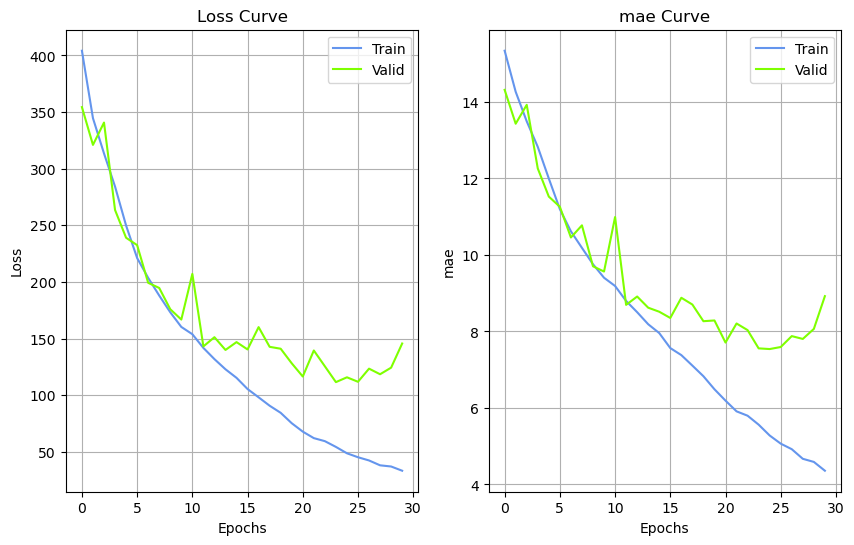

In [2]:
%run scripts/train.py --config configs/linear_regression_untrained.yaml

# Evaluate randomly initialized ResNet18

In [1]:
%run scripts/evaluate.py --config configs/linear_regression_untrained.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_regression_untrained.pth

Model Parameters = 11,177,025


100%|###########################################################################################################################################| 76/76 [00:30<00:00,  2.53it/s, loss=114]


Evaluation Metrics — linear_regression_untrained
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   7.4680 |
| MSE    | 114.3629 |
| Acc@3  |   0.3364 |
| Acc@5  |   0.4961 |
+--------+----------+


# Plot Validation MAE by Epochs


Epochs 0-10: Best Val MAE = 9.5669
Epochs 0-20: Best Val MAE = 8.2686
Epochs 0-30: Best Val MAE = 7.5404


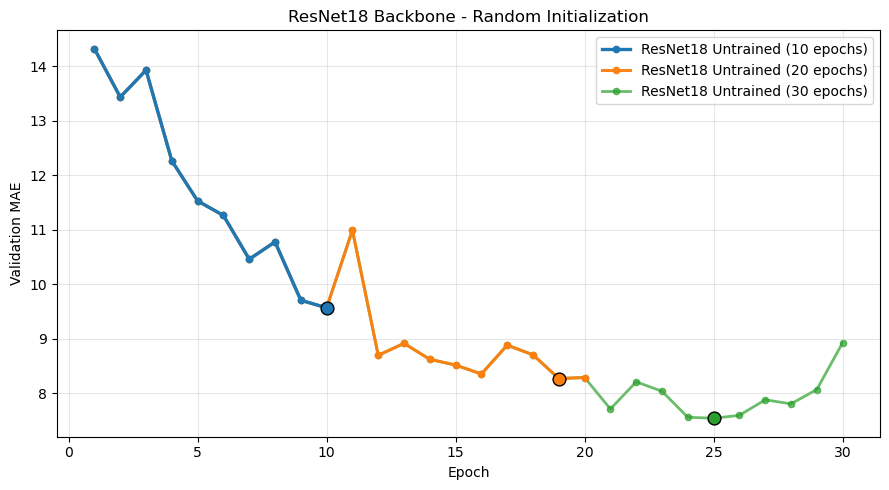

In [4]:
import numpy
from src.utils.plots import plot_validation_curves
# Load the file into a variable
data = numpy.load('outputs/stats_history_linear_regression_untrained.npy', allow_pickle=True).item()

plot_validation_curves(data['eval'], title='ResNet18 Backbone - Random Initialization', label='ResNet18 Untrained')